# A. Import data

In [2]:
import os
os.chdir("../../")

In [3]:
#pd.read_csv(f"{final_path}/sentiment_all_results.csv").text_clean.to_list()[0]

In [6]:
import pandas as pd
final_path = 'data/autoecon/mps'
final_path = 'data/autoecon/mp_statements'
final_path = 'data/autoecon/mps_speeches'
final_path = 'data/autoecon/test'
final_path = 'data/sentiment/statements_speeches'
final_path = 'data/sentiment/statements_speeches_250820'
final_path = 'data/sentiment/statements_speeches_250826'
os.listdir(final_path)

['sentiment_transformer_probabilities.csv',
 'sentiment_lexical.csv',
 'cleaned.parquet.gzip',
 'sentiment_all_results.csv',
 'cleaned_sentences.parquet.gzip',
 'transformers',
 'sentiment_transformers.csv']

## A.1 Cleaned full-text and sentences

In [7]:
df_sents = pd.read_parquet(f"{final_path}/cleaned_sentences.parquet.gzip")
df_sents.head(2)

,Unnamed: 0.1,date,type,link,release_date,id_text,text_tokens_str,text_sentence,id_sentence,id_textsent,len_sent
0,245,1994-02-04,Policy Statement,https://www.federalreserve.gov/fomc/19940322de...,1994-02-04,1,chairman alan greenspan announced today that t...,Chairman Alan Greenspan announced today that t...,1,1_1,152
1,245,1994-02-04,Policy Statement,https://www.federalreserve.gov/fomc/19940322de...,1994-02-04,1,chairman alan greenspan announced today that t...,This action is expected to be associated with ...,2,1_2,105


In [8]:
#df_sents.len_sent.describe()
#df_sents.query("len_sent>500")['text_sentence'].to_list()
#df_sents.query("len_sent<50")['text_sentence'].to_list()

In [9]:
df_text = pd.read_parquet(f"{final_path}/cleaned.parquet.gzip")
df_text.head(2)

,Unnamed: 0.1,Unnamed: 0,date,text,type,event,link,title,speaker,text_len,release_date,id_text,text_clean,text_tokens,text_tokens_str,text_stems,text_sentences,text_sentence
0,245,0,1994-02-04,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940322de...,None,None,NaN,1994-02-04,1,Chairman Alan Greenspan announced today that t...,"[chairman, alan, greenspan, announced, today, ...",chairman alan greenspan announced today that t...,chairman alan greenspan announc today that the...,[Chairman Alan Greenspan announced today that ...,[Chairman Alan Greenspan announced today that ...
1,246,1,1994-03-22,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940204de...,None,None,NaN,1994-03-22,2,Chairman Alan Greenspan announced today that t...,"[chairman, alan, greenspan, announced, today, ...",chairman alan greenspan announced today that t...,chairman alan greenspan announc today that the...,[Chairman Alan Greenspan announced today that ...,[Chairman Alan Greenspan announced today that ...


## A.2 Results
### A.2.1 All sentiment

In [10]:
df_sentiment_all = pd.read_csv(f"{final_path}/sentiment_all_results.csv", index_col = 'date', parse_dates=True)
df_sentiment_all.head(2).loc[:, 'text_sentences':]

,text_sentences,correa_sentiment_pos,correa_sentiment_pos_stem,correa_sentiment_alt,correa_sentiment_alt_stem,hubert_sentiment_pos,hubert_sentiment_pos_stem,hubert_sentiment_alt,hubert_sentiment_alt_stem,lm_sentiment_pos,...,ap_sentiment_pos,ap_sentiment_pos_stem,ap_sentiment_alt,ap_sentiment_alt_stem,gpt_sentiment_alt,fomc_sentiment_bysentence,gtstance_sentiment_bysentence,cbroberta_sentiment_bysentence,finbertpro_sentiment_bysentence,finbertyi_sentiment_bysentence
date,,,,,,,,,,,,,,,,,,,,,
1994-02-04,['Chairman Alan Greenspan announced today that...,1.0,1.0,1.000000,1.0,2.0,1.0,1.083333,1.0,1.0,...,1.0,2.0,1.0,1.080000,0.0,-1.0,1.0,-1.0,0.0,-1.0
1994-03-22,['Chairman Alan Greenspan announced today that...,2.0,1.0,1.018868,1.0,2.0,1.0,1.037736,1.0,1.0,...,1.0,2.0,1.0,1.034483,0.0,-1.0,1.0,0.0,-1.0,-1.0


### A.2.2 Label probabilities for each sentence

In [11]:
df_sentiment_prob = pd.read_csv(f"{final_path}/sentiment_transformer_probabilities.csv")
df_sentiment_prob['id_textsent'] = df_sentiment_prob['id_text'].astype(str) + '_' + df_sentiment_prob['id_sentence'].astype(str)
df_sentiment_prob.head(2)

,id_text,id_sentence,fomc_positive,fomc_negative,fomc_neutral,gtstance_negative,gtstance_positive,gtstance_neutral,gtstance_irrelevant,cbroberta_negative,cbroberta_positive,finbertpro_neutral,finbertpro_positive,finbertpro_negative,finbertyi_neutral,finbertyi_positive,finbertyi_negative,id_textsent
0,1,1,0.000638,0.999227,0.000135,0.008686,0.966473,0.023884,0.000957,0.605333,0.394667,0.781215,0.041403,0.177382,0.012753,0.000048,0.987200,1_1
1,1,2,0.000429,0.998085,0.001486,0.014683,0.965079,0.019564,0.000675,0.764364,0.235636,0.777493,0.012941,0.209566,0.998458,0.000717,0.000824,1_2


In [12]:
### SANITY CHECK LABEL PROBTS

In [13]:
pd.set_option('display.max_colwidth', 500)

df_sanity = pd.concat([df_sents[['date', 'text_sentence', 'id_sentence','id_textsent', 'len_sent', ]],df_sentiment_prob], axis=1)
df_sanity.iloc[1:, :].head(2)

,date,text_sentence,id_sentence,id_textsent,len_sent,id_text,id_sentence,fomc_positive,fomc_negative,fomc_neutral,...,gtstance_irrelevant,cbroberta_negative,cbroberta_positive,finbertpro_neutral,finbertpro_positive,finbertpro_negative,finbertyi_neutral,finbertyi_positive,finbertyi_negative,id_textsent
1,1994-02-04,This action is expected to be associated with a small increase in short-term money market interest rates.,2,1_2,105,1,2,0.000429,0.998085,0.001486,...,0.000675,0.764364,0.235636,0.777493,0.012941,0.209566,0.998458,0.000717,0.000824,1_2
2,1994-03-22,Chairman Alan Greenspan announced today that the Federal Open Market Committee decided to increase slightly the degree of pressure on reserve positions.,1,2_1,152,2,1,0.000638,0.999227,0.000135,...,0.000957,0.605333,0.394667,0.781215,0.041403,0.177382,0.012753,0.000048,0.987200,2_1


## A.3 Merge

In [18]:
df_merge = pd.merge(
    df_sents[['date', 'id_text', 'id_sentence', 'text_sentence', 'id_textsent']],
    df_sentiment_prob.drop(['id_textsent'], axis='columns'),
    on = ['id_text', 'id_sentence'],
    #how = 'outer'
    how = 'inner',
)
df_merge.head(2)

,date,id_text,id_sentence,text_sentence,id_textsent,fomc_positive,fomc_negative,fomc_neutral,gtstance_negative,gtstance_positive,gtstance_neutral,gtstance_irrelevant,cbroberta_negative,cbroberta_positive,finbertpro_neutral,finbertpro_positive,finbertpro_negative,finbertyi_neutral,finbertyi_positive,finbertyi_negative
0,1994-02-04,1,1,Chairman Alan Greenspan announced today that the Federal Open Market Committee decided to increase slightly the degree of pressure on reserve positions.,1_1,0.000638,0.999227,0.000135,0.008686,0.966473,0.023884,0.000957,0.605333,0.394667,0.781215,0.041403,0.177382,0.012753,0.000048,0.987200
1,1994-02-04,1,2,This action is expected to be associated with a small increase in short-term money market interest rates.,1_2,0.000429,0.998085,0.001486,0.014683,0.965079,0.019564,0.000675,0.764364,0.235636,0.777493,0.012941,0.209566,0.998458,0.000717,0.000824


### A.3.1 Convert to raw transformer output

In [32]:
column_mapping = {
    # FOMC columns (Unchanged)
    "fomc_positive": "LABEL_0",
    "fomc_negative": "LABEL_1",
    "fomc_neutral": "LABEL_2",
    # GTStance columns (Unchanged)
    "gtstance_negative": "LABEL_0",
    "gtstance_positive": "LABEL_1",
    "gtstance_neutral": "LABEL_2",
    "gtstance_irrelevant": "LABEL_3",
    # CBRoberta columns (Corrected)
    "cbroberta_negative": "negative",
    "cbroberta_positive": "positive",
    # FinBertPro columns (Corrected)
    "finbertpro_neutral": "neutral",
    "finbertpro_positive": "positive",
    "finbertpro_negative": "negative",
    # FinBertYi columns (Corrected)
    "finbertyi_neutral": "Neutral",
    "finbertyi_positive": "Positive",
    "finbertyi_negative": "Negative"
}

index_cols = ['date', 'id_text', 'id_sentence', 'text_sentence', 'id_textsent']
for dict in ['fomc', 
             'gtstance', 
             'cbroberta', 'finbertyi', 'finbertpro'
             ]:
    df_merge_dict = df_merge.set_index(index_cols).filter(regex= dict)
    df_merge_dict = df_merge_dict.rename(column_mapping, axis=1).round(3).reset_index()
    df_merge_dict.to_csv(f"{final_path}/transformers/probabilities_{dict}_raw.csv")

df_merge_dict.head(2)

,date,id_text,id_sentence,text_sentence,id_textsent,neutral,positive,negative
0,1994-02-04,1,1,Chairman Alan Greenspan announced today that the Federal Open Market Committee decided to increase slightly the degree of pressure on reserve positions.,1_1,0.781,0.041,0.177
1,1994-02-04,1,2,This action is expected to be associated with a small increase in short-term money market interest rates.,1_2,0.777,0.013,0.210


In [14]:
df_sents.shape[0] - df_sentiment_prob.shape[0] 
#df_sentiment_prob.id_textsent.unique().tolist() 

0

In [15]:
df_sents.shape[0] - df_sentiment_prob.shape[0] 
set1 = set(df_sentiment_prob.id_textsent.unique())
set2 = set(df_sents.id_textsent.unique())
result = list(set2 - set1)
missing_sents_from_sentence_df  = list(result)
missing_sents_from_sentence_df[:2]

[]

In [16]:
df_sents.query("id_textsent in @missing_sents_from_sentence_df")

,Unnamed: 0.1,date,type,link,release_date,id_text,text_tokens_str,text_sentence,id_sentence,id_textsent,len_sent


In [33]:
#[text_id for text_id in df_sentiment_prob.id_textsent.unique().tolist() if text_id not in  df_merge.id_textsent.unique().tolist()]
unique_text_ids = list(set(df_sentiment_prob.id_textsent.unique().tolist()) & set(df_merge.id_textsent.unique().tolist()))
result = [text_id for text_id in unique_text_ids if text_id not in df_merge.id_textsent.unique().tolist()]
result

KeyboardInterrupt: 

In [48]:
[text_id for text_id in df_sents.id_text.unique().tolist() if text_id not in   df_sentiment_prob.id_text.unique().tolist()]

[]

# 1. Compare aggregation method

In [11]:
sentiment_columns = [
     'correa_sentiment_pos', 'correa_sentiment_alt', 'hubert_sentiment_pos',
       'hubert_sentiment_alt', 'lm_sentiment_pos', 'lm_sentiment_alt',
       'hiv_sentiment_pos', 'hiv_sentiment_alt',
       'gtstance_sentiment_bysentence', 'cbroberta_sentiment_bysentence',
       'finbertpro_sentiment_bysentence', 'finbertyi_sentiment_bysentence'
]
df_sentiment_all.resample("ME")[sentiment_columns].mean().describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
correa_sentiment_pos,340.0,0.99,0.27,0.27,0.83,0.96,1.10,2.00
correa_sentiment_alt,340.0,1.00,0.01,0.98,0.99,1.00,1.00,1.02
hubert_sentiment_pos,340.0,1.30,0.28,0.00,1.15,1.31,1.44,2.00
hubert_sentiment_alt,340.0,1.01,0.01,0.98,1.00,1.00,1.01,1.09
lm_sentiment_pos,340.0,0.93,0.23,0.00,0.79,0.91,1.02,2.00
lm_sentiment_alt,340.0,0.99,0.01,0.95,0.98,0.99,1.00,1.04
hiv_sentiment_pos,340.0,1.37,0.15,0.67,1.29,1.38,1.46,2.00
hiv_sentiment_alt,340.0,1.03,0.01,0.98,1.02,1.03,1.04,1.11
gtstance_sentiment_bysentence,340.0,-0.70,0.29,-1.00,-0.86,-0.75,-0.64,1.00
cbroberta_sentiment_bysentence,340.0,-0.25,0.24,-1.00,-0.39,-0.26,-0.11,1.00


In [12]:
df_sentiment_all.resample("ME")[sentiment_columns].mean().diff(1).describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
correa_sentiment_pos,325.0,0.01,0.29,-1.00,-0.15,-0.01,0.16,1.00
correa_sentiment_alt,325.0,0.00,0.01,-0.02,-0.00,0.00,0.01,0.02
hubert_sentiment_pos,325.0,-0.00,0.29,-1.56,-0.16,0.00,0.18,1.42
hubert_sentiment_alt,325.0,-0.00,0.01,-0.07,-0.00,-0.00,0.00,0.05
lm_sentiment_pos,325.0,0.00,0.24,-0.61,-0.14,0.02,0.16,1.00
lm_sentiment_alt,325.0,-0.00,0.02,-0.05,-0.01,0.00,0.01,0.07
hiv_sentiment_pos,325.0,-0.00,0.18,-0.69,-0.12,0.01,0.11,0.71
hiv_sentiment_alt,325.0,0.00,0.02,-0.06,-0.01,-0.00,0.01,0.09
gtstance_sentiment_bysentence,325.0,-0.00,0.21,-0.80,-0.11,-0.01,0.12,0.74
cbroberta_sentiment_bysentence,325.0,0.00,0.33,-1.02,-0.19,0.00,0.22,1.33


# PREVIOUS CODE

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

sentiment_dict = {
    'correa_sentiment_pos' : "Correa (Pos-Neg Tokens)",
    'lm_sentiment_pos' : "Loughran-McDonald (Pos-Neg Tokens)",
    'correa_sentiment_alt' : "Correa (All Tokens)",
    'lm_sentiment_alt' : "Loughran-McDonald (All Tokens)",
    'hubert_sentiment_alt' : "Hubert (Pos-Neg Tokens)",
    'hubert_sentiment_alt' : "Hubert (All Tokens)",

}

lexical_pos = ['correa_sentiment_pos',
               'lm_sentiment_pos',
                #'hubert_sentiment_pos',
                 #'hiv_sentiment_pos'
              ]
lexcial_alt = [
    'correa_sentiment_alt',
     'lm_sentiment_alt',
     #'hiv_sentiment_alt',
     #'hubert_sentiment_alt'
                  ]
df = df_sentiment_all
df.index = pd.to_datetime(df.index)
df = df['2007':]
##df.index = [x.strftime("%Y-%b") for x in df.index]
# Extract the data to be plotted on the primary axis
primary_y = df[lexcial_alt].rename(columns = sentiment_dict)
primary_y
# Extract the data to be plotted on the secondary axis
secondary_y = df[lexical_pos].rename(columns = sentiment_dict)
secondary_y
# Plotting
fig, ax1 = plt.subplots(figsize = (30, 16))

plt.style.use('references/viz/line_chart.mplstyle')

# Plot primary_y data
primary_y.plot(ax=ax1, style='--')
ax1.set_xlabel('Index')
ax1.set_ylabel('Denominator (All Tokens)')
ax1.legend(loc='upper left')

# Create a second y-axis for the secondary data
ax2 = ax1.twinx()
secondary_y.plot(ax=ax2, style='-')
ax2.set_ylabel('Denominator (Pos-Neg Tokens)')

ax1.set_xlabel('')
ax1.set_title('Lexical Aggregation Comparison')

# Manually combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='lower center', ncol = 2, bbox_to_anchor = (.5, -.3))
ax2.get_legend().remove()
# Improve plot aesthetics
#fig.tight_layout()
ax1.tick_params(axis='x', rotation=0)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


save = False
if save:
    plt.savefig(
        "overleaf/paper/Figures/sentiment_compare/aggregation_compare_graph.pdf",
        format='pdf',
        bbox_inches='tight',
        dpi=300
        
    )
    # Show plot
    plt.show()

## 2. Compare Transformers

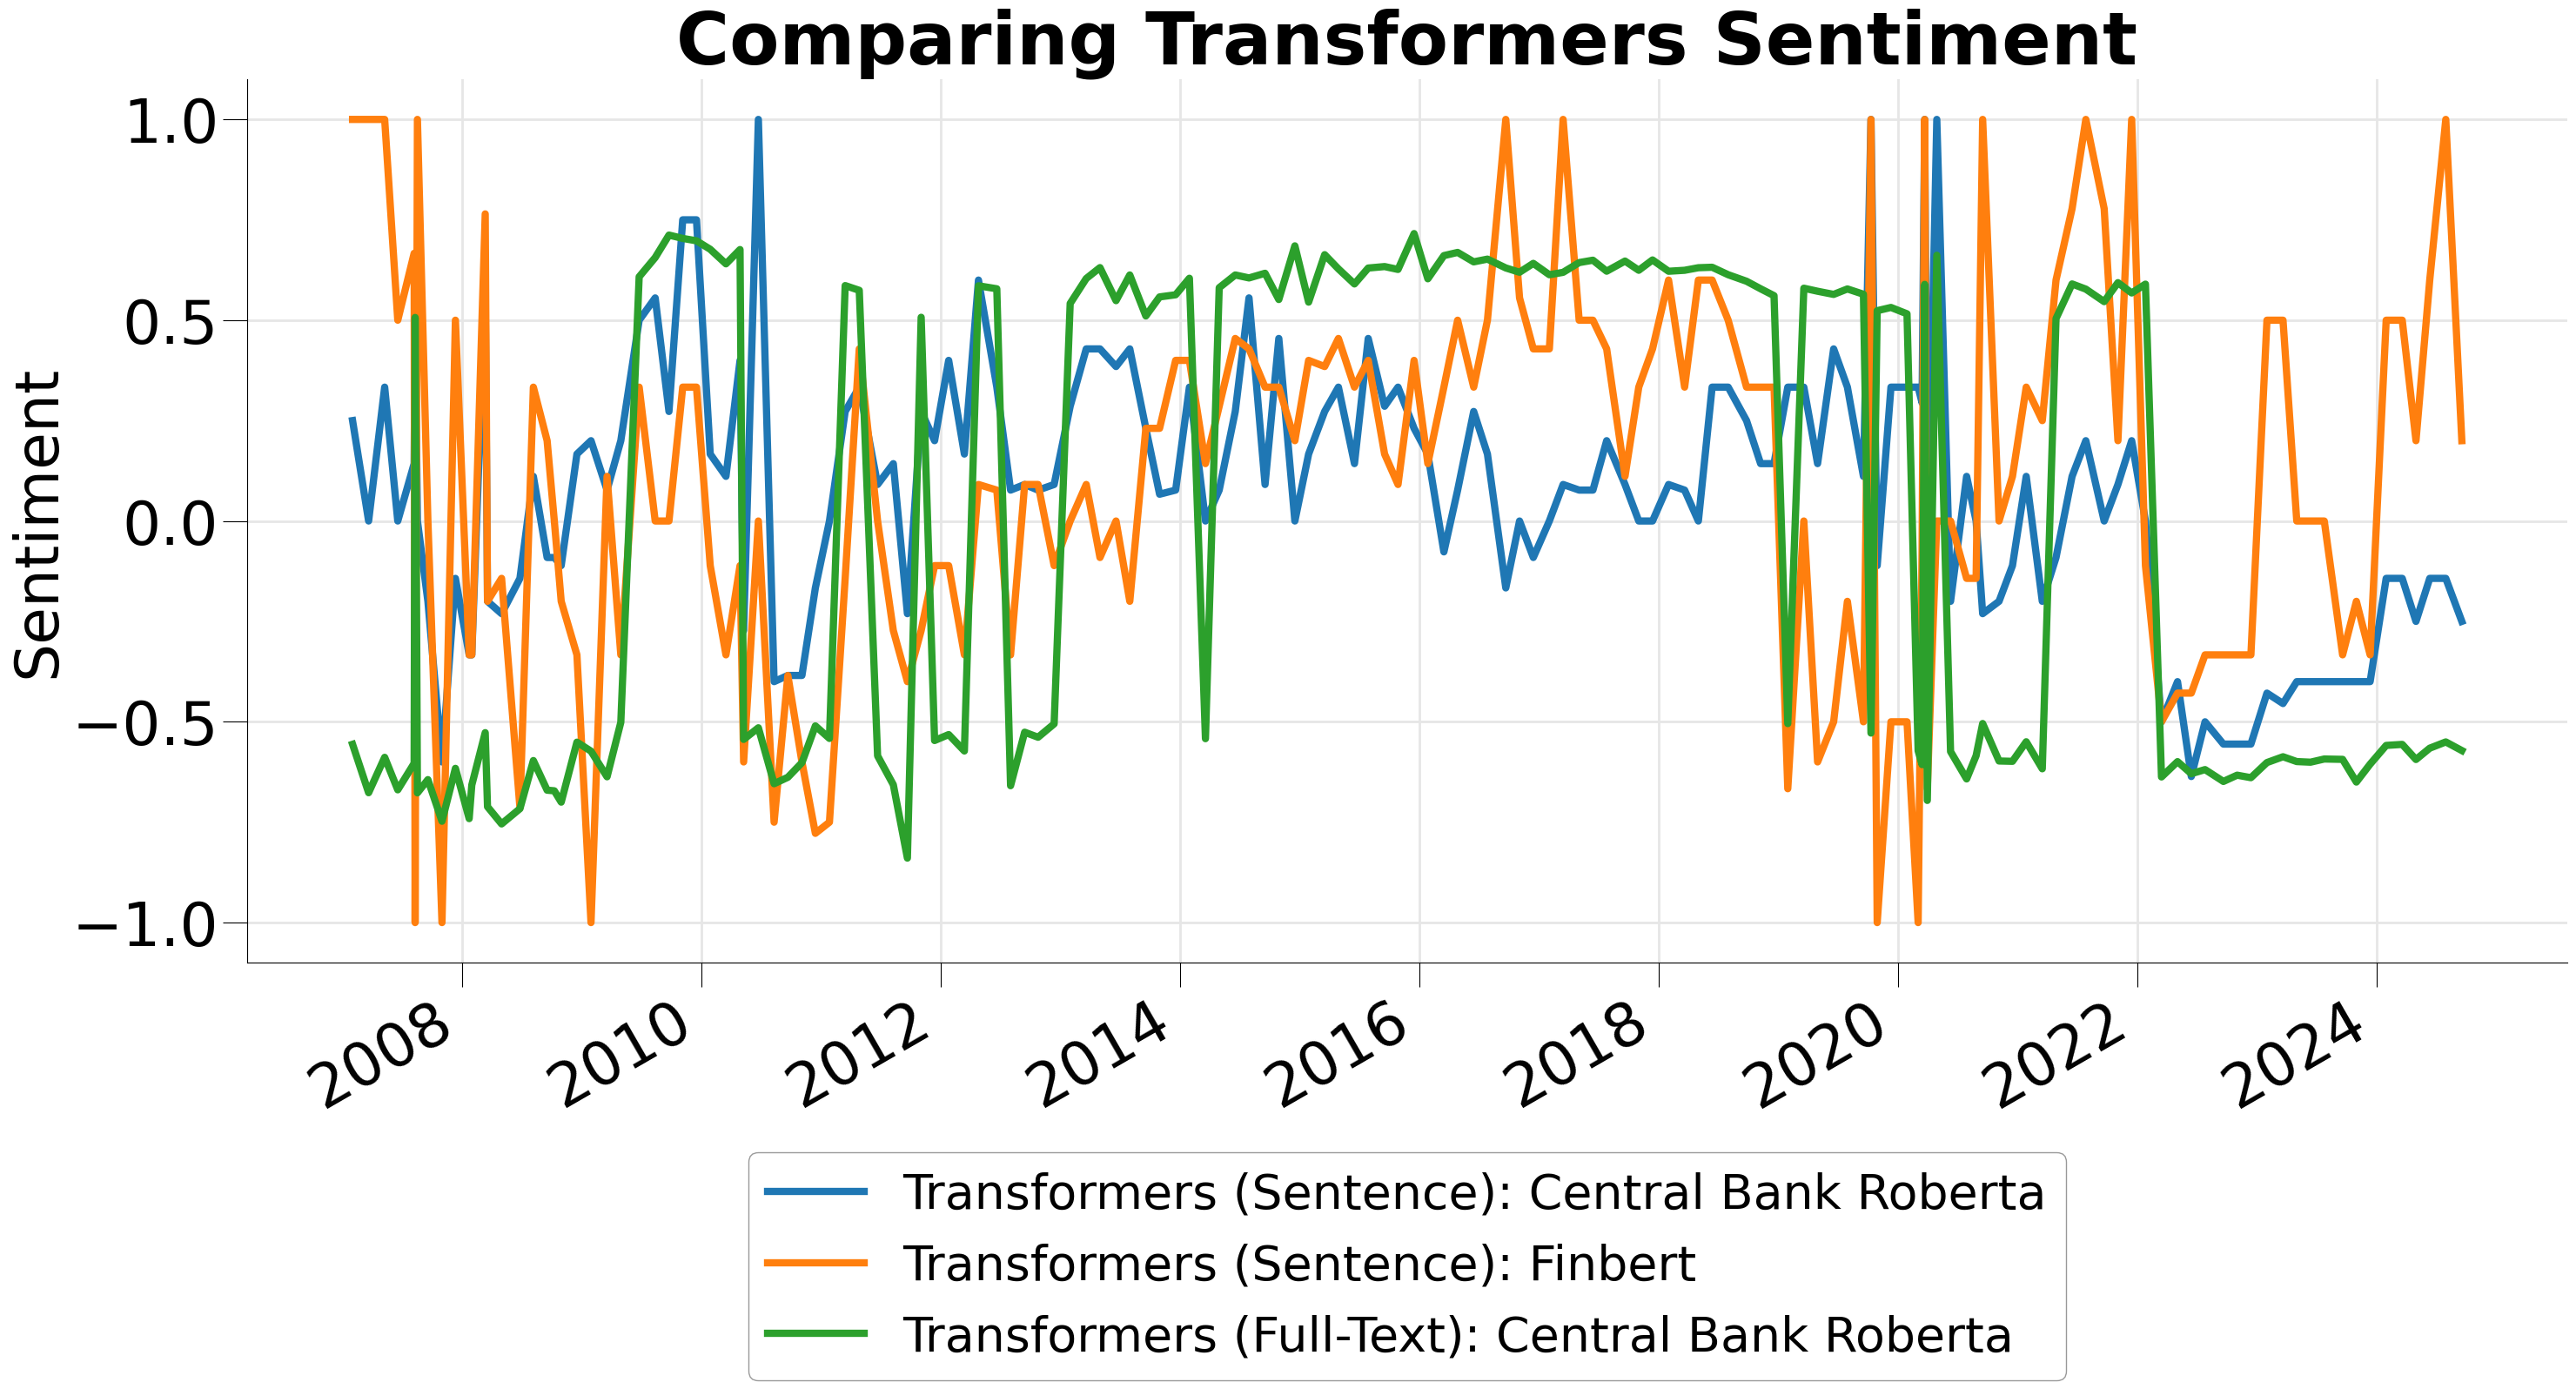

In [33]:

sentiment_dict = {
    'cbroberta_sentiment_bysentence' : "Transformers (Sentence): Central Bank Roberta",
    'finbert_sentiment_bysentence' : "Transformers (Sentence): Finbert",
    'cbroberta_sentiment_byalltext' : "Transformers (Full-Text): Central Bank Roberta",

}

plt.style.use('references/viz/line_chart.mplstyle')

transformers_sentence = ['cbroberta_sentiment_bysentence','finbert_sentiment_bysentence', 'cbroberta_sentiment_byalltext']
fig, ax = plt.subplots(figsize = (30, 16))
df[transformers_sentence].rename(columns = sentiment_dict).plot(ax = ax)
plt.xlabel("")
plt.legend( loc='lower center', ncol = 1, bbox_to_anchor = (.5, -.5), fontsize = 40)
plt.ylabel("Sentiment")
plt.title("Comparing Transformers Sentiment")

save = False
if save:
    plt.savefig(
        "overleaf/paper/Figures/sentiment_compare/transformers_compare.pdf",
        format='pdf',
        bbox_inches='tight',
        dpi=300
        
    )

## 3. Comparing Lexical to Transformers

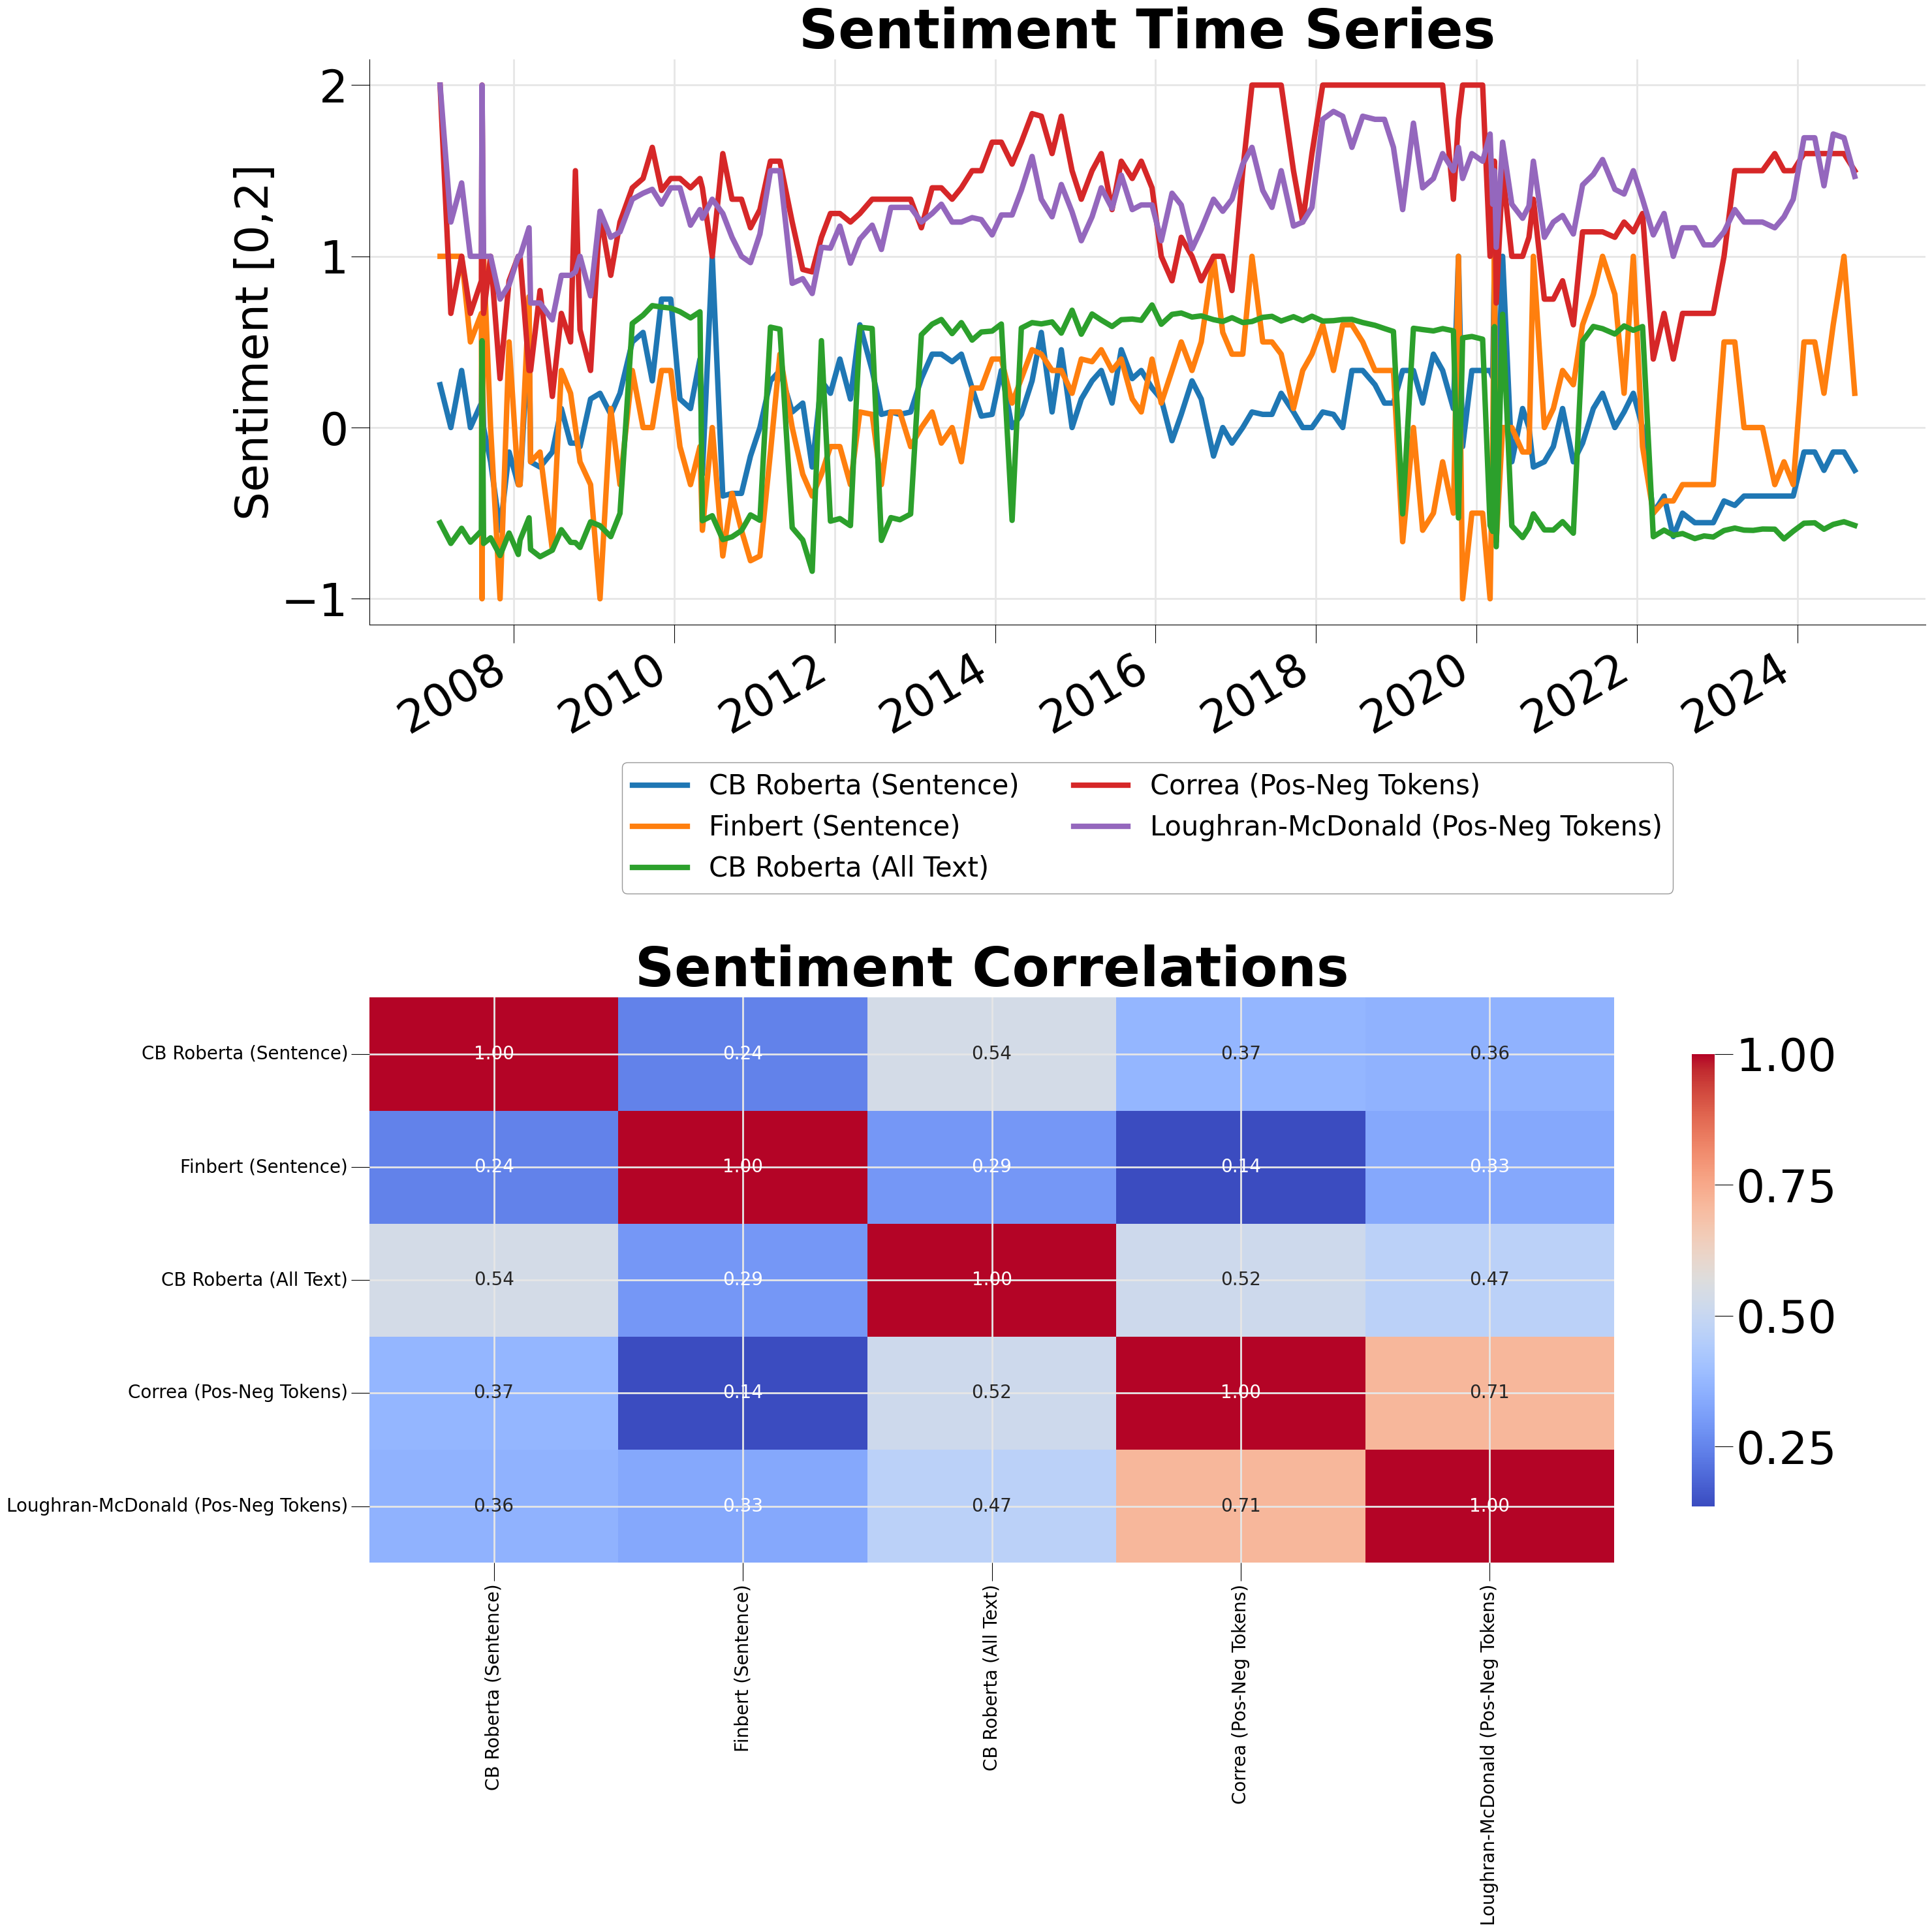

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('references/viz/line_chart.mplstyle')

sentiment_dict = {
    'cbroberta_sentiment_bysentence' : "CB Roberta (Sentence)",
    'finbert_sentiment_bysentence' : "Finbert (Sentence)",
    'cbroberta_sentiment_byalltext' : "CB Roberta (All Text)",

    'correa_sentiment_pos' : "Correa (Pos-Neg Tokens)",
    'lm_sentiment_pos' : "Loughran-McDonald (Pos-Neg Tokens)",
    'correa_sentiment_alt' : "Correa (All Tokens)",
    'lm_sentiment_alt' : "Loughran-McDonald (All Tokens)",
    'hubert_sentiment_alt' : "Hubert (Pos-Neg Tokens)",
    'hubert_sentiment_alt' : "Hubert (All Tokens)",

}
# Transformers lexical columns
transformers_lexcial = [
    'cbroberta_sentiment_bysentence', 'finbert_sentiment_bysentence',
    'cbroberta_sentiment_byalltext', 'correa_sentiment_pos', 'lm_sentiment_pos'
]

# Subplots creation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 30))

# Time Series Plot
df[transformers_lexcial].rename(columns = sentiment_dict).plot(ax=ax1)
ax1.set_title('Sentiment Time Series')
ax1.set_xlabel('')
ax1.set_ylabel('Sentiment [0,2]')
ax1.legend( loc='lower center', ncol = 2, bbox_to_anchor = (.5, -.5), fontsize = 30)
# Correlation Heatmap
corr_matrix = df[transformers_lexcial].rename(columns = sentiment_dict).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax2, cmap='coolwarm', cbar_kws={'shrink': .8})
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax2.set_title('Sentiment Correlations')
#ax1.legend()
fig.subplots_adjust(
    hspace = 2
)
# Adjust layout
#plt.tight_layout()

save = False
if save:
    plt.savefig(
        "overleaf/paper/Figures/sentiment_compare/sentiment_ts_heatmap.pdf",
        format='pdf',
        bbox_inches='tight',
        dpi=300)
        

# 2. Transformer test data

In [38]:
path = "data/test/sentiment_output/transformers"

## 2.1 Generate label by entire text

In [39]:
pd.read_csv(f"{path}/sentiment_cbroberta_byalltext.csv").filter(regex='sentiment')

,cbroberta_label_sentiment,cbroberta_sentiment_byalltext
0,1,0.965008
1,-1,-0.979625
2,-1,-0.961645
3,-1,-0.968037
4,-1,-0.972404
5,1,0.938103
6,-1,-0.956364


## 2.2 Generate sentiment for each sentence then aggregate

In [40]:
pd.read_csv(f"{final_path}/sentiment_cbroberta_bysentence_aggregated.csv").filter(regex='sentiment')

FileNotFoundError: [Errno 2] No such file or directory: 'data/autoecon/mps//sentiment_cbroberta_bysentence_aggregated.csv'

### 2.2.1 Show each sentence sentiment to generate aggregate

In [19]:
pd.read_csv(f"{path}/sentiment_cbroberta_bysentence.csv")

,Unnamed: 0,index,text,id_text,cbroberta_predicted_label,cbroberta_probability_0,cbroberta_probability_1,cbroberta_label,cbroberta_label_sentiment,cbroberta_sentiment
0,0,0,The tech giant announced record profits for th...,1,1,0.064858,0.935142,positive,1,0.935142
1,1,1,Their innovative product line continues to dri...,1,1,0.018118,0.981882,positive,1,0.981882
2,2,2,The company's stock price jumped 5% on the pos...,1,1,0.061419,0.938581,positive,1,0.938581
3,3,3,Analysts predict a strong finish to the fiscal...,1,1,0.092991,0.907009,positive,1,0.907009
4,4,4,Concerns about rising interest rates triggered...,2,0,0.974615,0.025385,negative,-1,-0.974615
5,5,5,Investors are worried about the potential impa...,2,0,0.976686,0.023314,negative,-1,-0.976686
6,6,6,Geopolitical tensions added to the negative ma...,2,0,0.975126,0.024874,negative,-1,-0.975126
7,7,7,Trading volume was significantly higher than t...,2,0,0.880436,0.119564,negative,-1,-0.880436
8,8,8,The company's earnings report revealed a subst...,3,0,0.956257,0.043743,negative,-1,-0.956257
9,9,9,Weak demand in key international markets furth...,3,0,0.981170,0.018830,negative,-1,-0.981170


In [2]:
from tqdm import tqdm  # For progress bars during loops or lengthy processes
import pandas as pd

file_path = 'text_data/'
from src.clean.text_loader import TextLoader
loader = TextLoader(file_path = file_path+'combined_text.csv', text_column = 'text', date_column = 'date')
df_raw = loader.get_data()
df_raw.head(2)

,Unnamed: 0,date,text,type,event,link,title,speaker,text_len,release_date
0,0,1994-02-04,A meeting of the Federal Open Market Committee...,Minutes,Minutes,https://www.federalreserve.gov/fomc/MINUTES/19...,NaN,NaN,NaN,1994-03-25
1,1,1994-03-22,A meeting of the Federal Open Market Committee...,Minutes,Minutes,https://www.federalreserve.gov/fomc/MINUTES/19...,NaN,NaN,NaN,1994-05-20


In [3]:
df_group_counts, df_text_stats, df_time_span, df_date_ranges = loader.get_summary_stats(group_by_column = 'type')
df_group_counts

,count,count
0,Speech,1702
1,Minutes,245
2,Policy Statement,232
3,Beige Book,224


# 2. Time series

In [4]:
import pandas as pd
df_sentiment_all = pd.read_csv("text_data/combined_labels.csv")
df_sentiment_all.date = pd.to_datetime(df_sentiment_all.date)
df_sentiment_all.head(2)

,date,release_date,type,count_cbroberta_all_total,count_pos_cbroberta_all,count_neg_cbroberta_all,sentiment_cbroberta_all_pos,sentiment_cbroberta_all_alt,count_finbert_total,count_pos_finbert,...,count_lm_total,count_pos_lm,count_neg_lm,sentiment_lm_pos,sentiment_lm_alt,count_hiv_total,count_pos_hiv,count_neg_hiv,sentiment_hiv_pos,sentiment_hiv_alt
0,1994-02-04,1994-02-04,Policy Statement,1,0,1,0.000000,-1.000000,2,2,...,0,0,0,NaN,NaN,0,0,0,NaN,NaN
1,1994-02-04,1994-03-25,Minutes,215,91,124,0.846512,-0.153488,158,103,...,233,113,120,0.969957,-0.030043,278,202,76,1.453237,0.453237


## 2.1 All statement types

In [5]:
df_avg_all_types = df_sentiment_all.drop(['release_date', 'type'], axis=1).set_index(['date']).resample('M').mean()
df_avg_all_types.head(2)

/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_7053/365910089.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_avg_all_types = df_sentiment_all.drop(['release_date', 'type'], axis=1).set_index(['date']).resample('M').mean()


,count_cbroberta_all_total,count_pos_cbroberta_all,count_neg_cbroberta_all,sentiment_cbroberta_all_pos,sentiment_cbroberta_all_alt,count_finbert_total,count_pos_finbert,count_neg_finbert,sentiment_finbert_pos,sentiment_finbert_alt,...,count_lm_total,count_pos_lm,count_neg_lm,sentiment_lm_pos,sentiment_lm_alt,count_hiv_total,count_pos_hiv,count_neg_hiv,sentiment_hiv_pos,sentiment_hiv_alt
date,,,,,,,,,,,,,,,,,,,,,
1994-02-28,108.0,45.5,62.5,0.423256,-0.576744,80.0,52.5,27.5,1.651899,0.651899,...,116.5,56.5,60.0,0.969957,-0.030043,139.0,101.0,38.0,1.453237,0.453237
1994-03-31,82.5,25.0,57.5,0.800613,-0.199387,67.0,37.5,29.5,1.549618,0.549618,...,102.5,38.5,64.0,0.874384,-0.125616,98.5,60.5,38.0,0.951890,-0.048110


In [6]:
sentiment_dict = {
    'sentiment_cbroberta_all_pos' : "Transformers: Central Bank Roberta",
    'sentiment_finbert_pos' :  "Transformers: Finbert", 
    'sentiment_correa_pos' : "Lexcial: Correa",
    'sentiment_lm_pos' : "Lexical: Loughran-McDonald"
}

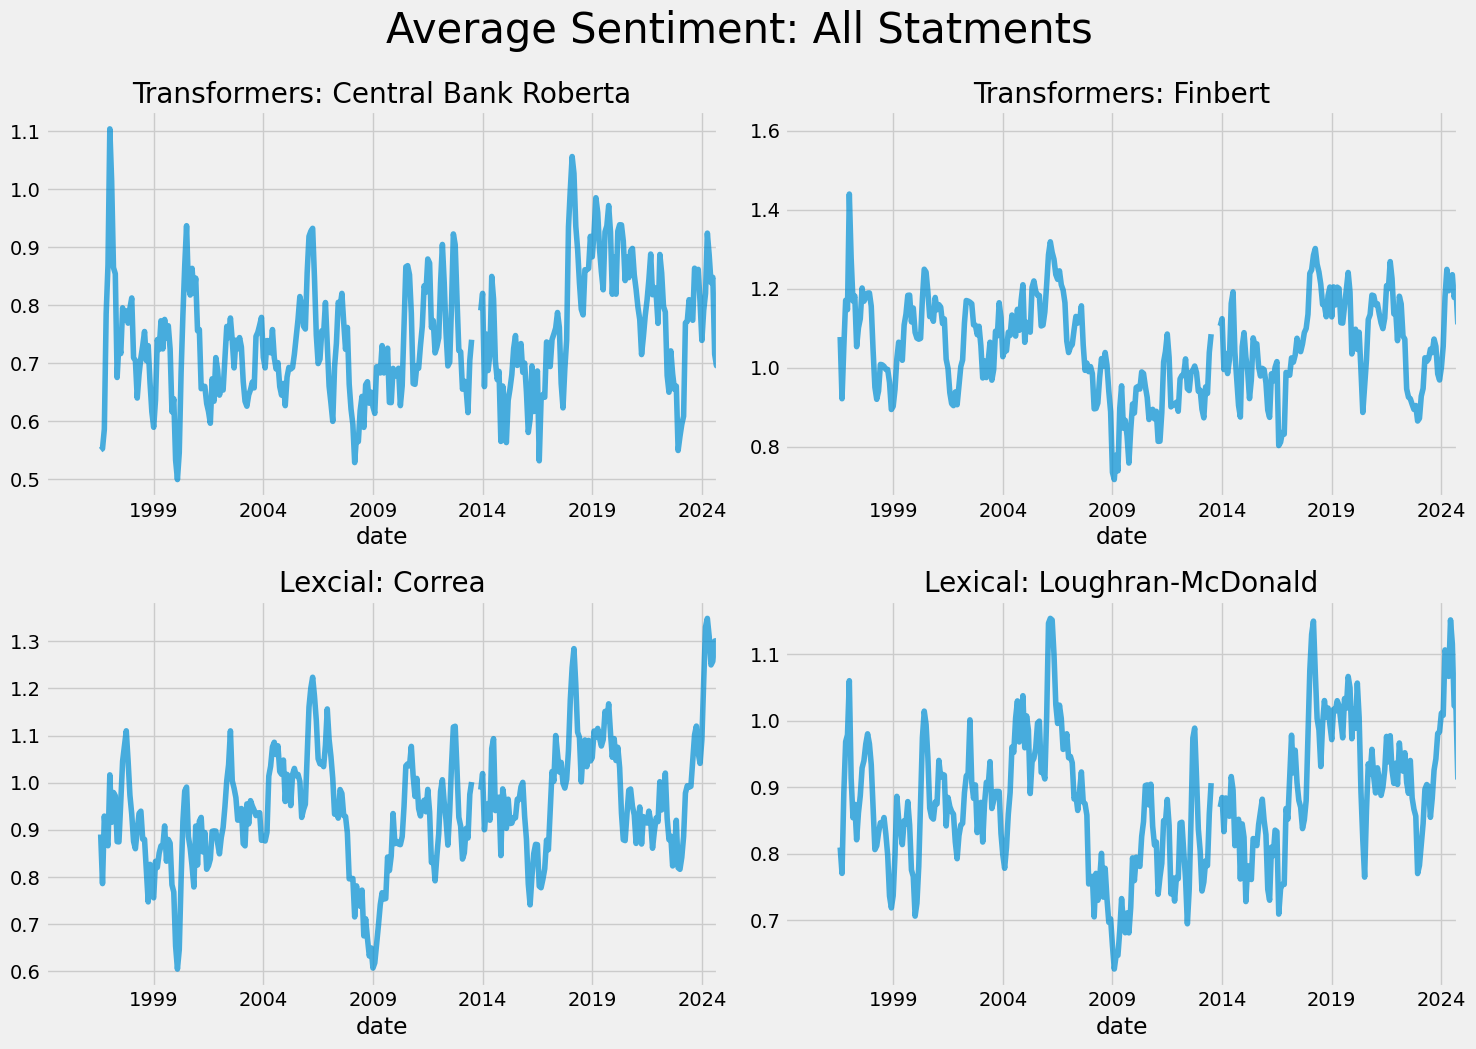

In [7]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # 2 rows, 2 columns
# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over the column names directly
for i, col in enumerate(['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']):
    df_avg_all_types[col].rolling(4).mean().plot(ax=axes[i], alpha=0.7)
    axes[i].set_title(sentiment_dict[col])

plt.tight_layout()
fig.suptitle("Average Sentiment: All Statments", y =1.05, size = 30)

#plt.savefig("overleaf/paper/figures/eda/sentiment_all_subplots.png", format = 'png', bbox_inches='tight')
plt.show()

## 2.2 Statements

In [8]:
df_statements = df_sentiment_all.query("type == 'Policy Statement'").set_index('date')
df_statements.head(2)

,release_date,type,count_cbroberta_all_total,count_pos_cbroberta_all,count_neg_cbroberta_all,sentiment_cbroberta_all_pos,sentiment_cbroberta_all_alt,count_finbert_total,count_pos_finbert,count_neg_finbert,...,count_lm_total,count_pos_lm,count_neg_lm,sentiment_lm_pos,sentiment_lm_alt,count_hiv_total,count_pos_hiv,count_neg_hiv,sentiment_hiv_pos,sentiment_hiv_alt
date,,,,,,,,,,,,,,,,,,,,,
1994-02-04,1994-02-04,Policy Statement,1,0,1,0.0,-1.0,2,2,0,...,0,0,0,NaN,NaN,0,0,0,NaN,NaN
1994-03-22,1994-03-22,Policy Statement,2,1,1,1.0,0.0,3,3,0,...,2,1,1,1.0,0.0,3,1,2,0.666667,-0.333333


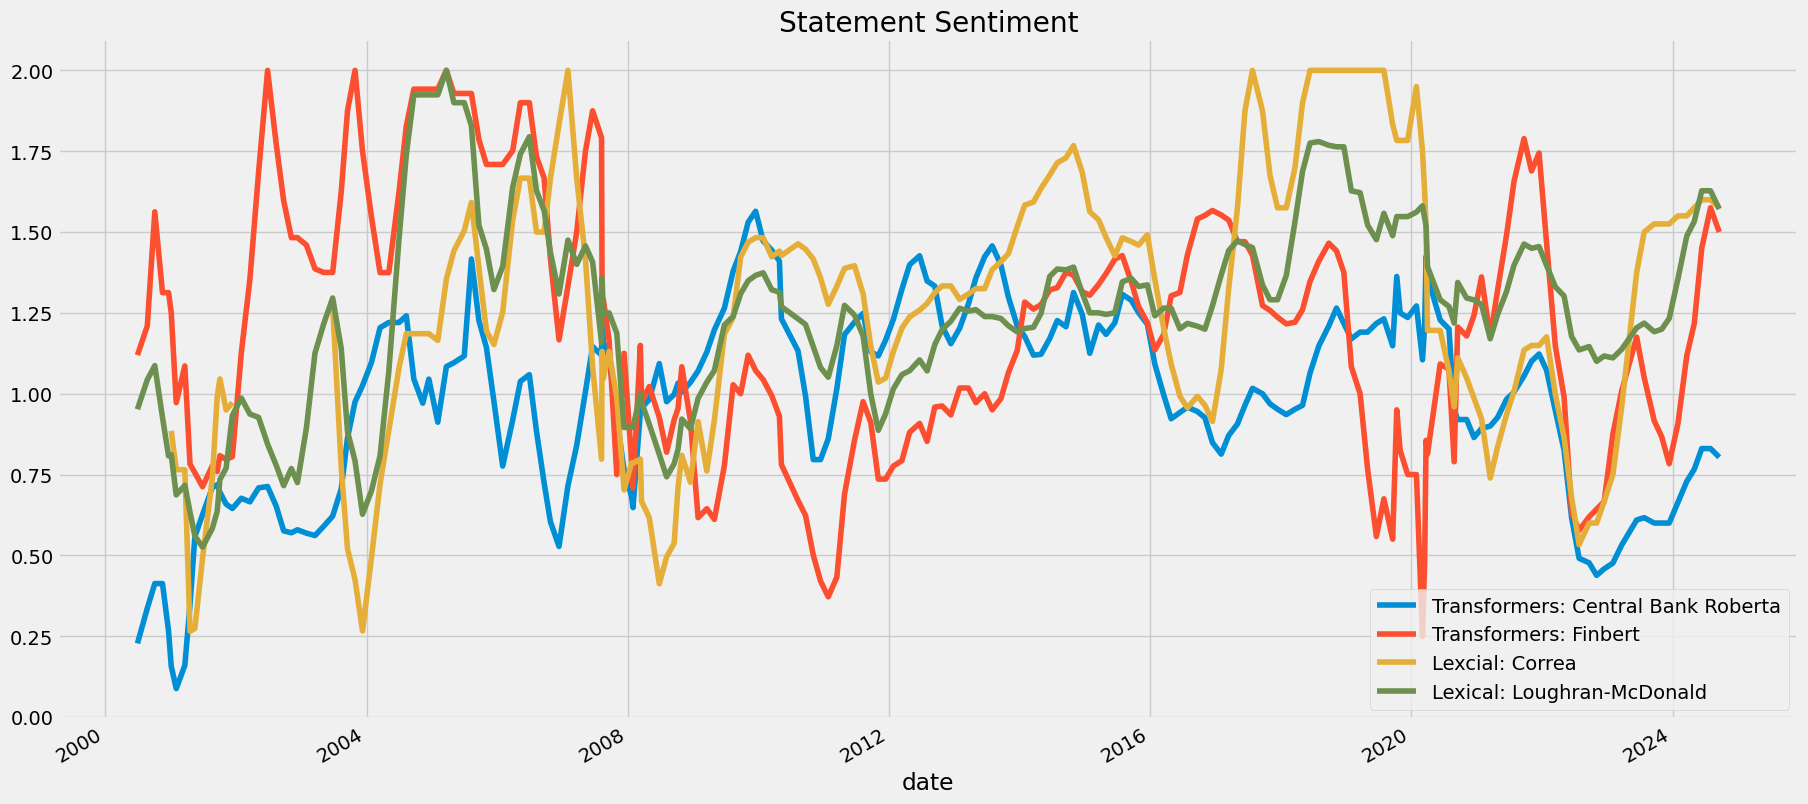

In [9]:
import matplotlib.pyplot as plt
df_statements['2000-01-01':][['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].rename(sentiment_dict, axis=1).rolling(4).mean().plot(figsize=(20, 10)) 
plt.legend(fontsize=14)  
plt.title('Statement Sentiment')
#plt.savefig("overleaf/paper/figures/eda/statement_sentiment_combined.png", format = 'png', bbox_inches='tight')
plt.show()

# 3. Compare Divergence

## 3.A Data

### 3.A.1 Text

In [10]:
df_diverge = df_sentiment_all.set_index('date')[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']]#.rename(sentiment_dict, axis=1)
df_diverge = pd.merge(df_raw.set_index("date")[['text', 'type']], df_diverge, right_index=True, left_index=True)
df_diverge.head(2)

,text,type,sentiment_cbroberta_all_pos,sentiment_finbert_pos,sentiment_correa_pos,sentiment_lm_pos
date,,,,,,
1994-02-04,A meeting of the Federal Open Market Committee...,Minutes,0.000000,2.000000,NaN,NaN
1994-02-04,A meeting of the Federal Open Market Committee...,Minutes,0.846512,1.303797,0.947368,0.969957


### 3.A.2 Market data via Fred

In [12]:
# import os
# from dotenv import load_dotenv
# load_dotenv("config/.config")  # Load environment variables from .env
# FRED_API_KEY = os.getenv('FRED_API')

# import datetime
# from fredapi import Fred
# def get_market_data_fredapi(start_date, end_date, api_key=FRED_API_KEY):
#     fred = Fred(api_key=api_key)
#     series = {"SP500": "SP500", "DGS10": "DGS10", "TB3MS": "TB3MS"}
#     data = {name: fred.get_series(code, start_date, end_date) for name, code in series.items()}
#     df = pd.DataFrame(data)
#     df.ffill(inplace=True)
#     df.dropna(inplace=True)
#     return df
# df_market = get_market_data_fredapi( datetime.date(1990, 1, 1), datetime.date(2024, 1, 1))
# df_market['SP500_pctch'] = df_market['SP500'].pct_change(1)
# df_market['DGS10_diff'] = df_market['DGS10'].diff(1)
# df_market['TB3MS_diff'] = df_market['TB3MS'].diff(1)
# df_market.index = pd.to_datetime(df_market.index)
# df_market.index.name = 'date'
# df_market.head(2)

In [ ]:
import numpy as np
df_diverge = pd.merge(df_diverge,df_market,right_index=True, left_index=True)
df_diverge = df_diverge.assign(
    sentiment_variance = df_diverge[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].apply(lambda sentiment_scores: np.var(sentiment_scores), axis=1).values,
    text_len = df_diverge['text'].str.len()
)
df_diverge.head(2)

In [13]:
df_largest = df_diverge.query("type == 'Policy Statement'")[df_diverge[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].notna().sum(axis=1).eq(4)].sort_values(['sentiment_variance','text_len'], ascending=False).head(20)
df_largest.head(5)

/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_47427/355986035.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_largest = df_diverge.query("type == 'Policy Statement'")[df_diverge[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].notna().sum(axis=1).eq(4)].sort_values(['sentiment_variance','text_len'], ascending=False).head(20)


,text,type,sentiment_cbroberta_all_pos,sentiment_finbert_pos,sentiment_correa_pos,sentiment_lm_pos,SP500_x,DGS10_x,TB3MS_x,SP500_pctch_x,DGS10_diff_x,TB3MS_diff_x,SP500_y,DGS10_y,TB3MS_y,SP500_pctch_y,DGS10_diff_y,TB3MS_diff_y,sentiment_variance,text_len
date,,,,,,,,,,,,,,,,,,,,
2019-10-30,"The Federal Reserve, the central bank of the U...",Policy Statement,0.800000,0.000000,2.0,1.454545,3046.77,1.78,1.65,0.003253,-0.06,0.00,3046.77,1.78,1.65,0.003253,-0.06,0.00,0.557603,3776
2020-03-03,"The Federal Reserve, the central bank of the U...",Policy Statement,1.333333,0.000000,1.0,1.714286,3003.37,1.02,0.29,-0.028108,-0.08,0.00,3003.37,1.02,0.29,-0.028108,-0.08,0.00,0.405187,2282
2019-01-30,"The Federal Reserve, the central bank of the U...",Policy Statement,1.142857,0.333333,2.0,1.272727,2681.05,2.70,2.37,0.015549,-0.02,0.00,2681.05,2.70,2.37,0.015549,-0.02,0.00,0.349753,3745
2019-05-01,"The Federal Reserve, the central bank of the U...",Policy Statement,1.142857,0.400000,2.0,1.400000,2923.73,2.52,2.35,-0.007502,0.01,-0.03,2923.73,2.52,2.35,-0.007502,0.01,-0.03,0.329541,3577
2019-12-11,"The Federal Reserve, the central bank of the U...",Policy Statement,1.142857,0.500000,2.0,1.600000,3141.63,1.79,1.54,0.002908,-0.06,0.00,3141.63,1.79,1.54,0.002908,-0.06,0.00,0.311059,3569


In [14]:
import numpy as np
largest_divergence = list(df_diverge.query("type == 'Policy Statement'")[df_diverge[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].notna().sum(axis=1).eq(4)].query('sentiment_finbert_pos!=0').sentiment_variance.sort_values(ascending=False).index[:10])
largest_divergence = list(np.unique(largest_divergence))
for date in largest_divergence:
    meeting = df_diverge.reset_index().query(f"date=='{date}'").drop_duplicates(['date'])
    print(f"Date: {meeting.date.iloc[0].strftime("%Y-%m-%d")}")
    #print(f"Text: {meeting.text.iloc[0]}")
    print("Text len: {:,}".format(len(meeting.text.iloc[0])))
    #print("\n\n")

Date: 2018-03-21
Text len: 49,819
Date: 2018-05-02
Text len: 48,754
Date: 2019-01-30
Text len: 94,225
Date: 2019-05-01
Text len: 70,227
Date: 2019-06-19
Text len: 63,430
Date: 2019-07-31
Text len: 56,493
Date: 2019-12-11
Text len: 74,768
Date: 2020-01-29
Text len: 88,924
Date: 2020-09-16
Text len: 60,301
Date: 2023-09-20
Text len: 44,170


/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_47427/2610251261.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  largest_divergence = list(df_diverge.query("type == 'Policy Statement'")[df_diverge[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].notna().sum(axis=1).eq(4)].query('sentiment_finbert_pos!=0').sentiment_variance.sort_values(ascending=False).index[:10])
/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_47427/2610251261.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  meeting = df_diverge.reset_index().query(f"date=='{date}'").drop_duplicates(['date'])
/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_47427/2610251261.py:5: FutureWarning: The behavior o

In [15]:
#.sentiment_variance.sort_values(ascending=False)

In [16]:
df_plot = df_diverge.loc['2019-01-30'].tail(1)[['text', 'sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']].rename(sentiment_dict, axis=0)
#df_plot[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']] = df[['sentiment_cbroberta_all_pos', 'sentiment_finbert_pos', 'sentiment_correa_pos', 'sentiment_lm_pos']]#.astype(float)

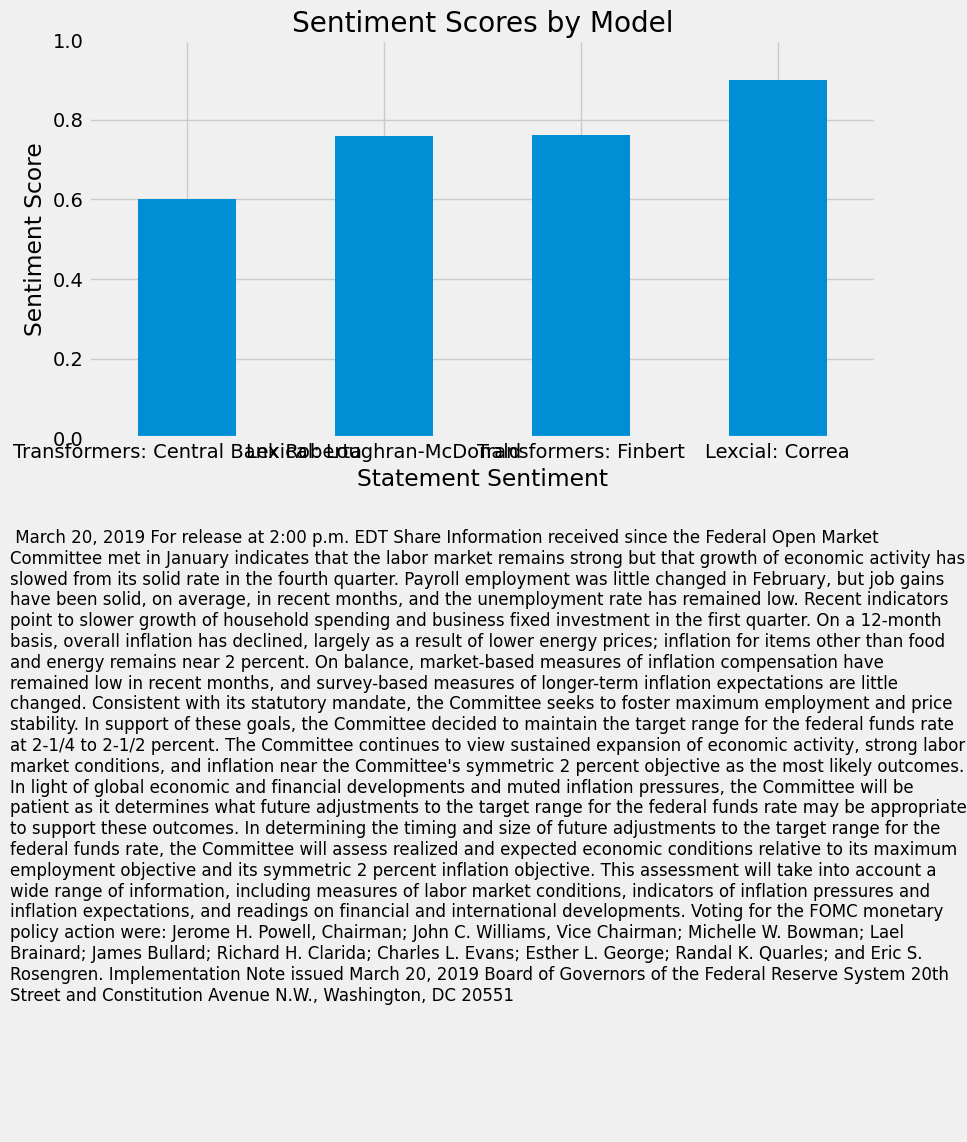

In [18]:
import re
text = df_plot['text'].iloc[0][:5000]
text = re.sub(r'\s+', ' ', text) # Replace one or more whitespace characters with a single space
text = text.replace("The Federal Reserve, the central bank of the United States, provides the nation with a safe, flexible, and stable monetary and financial system. Federal Open Market Committee Monetary Policy Principles and Practice Policy Implementation Reports Review of Monetary Policy Strategy, Tools, and Communications Institution Supervision Reports Reporting Forms Supervision & Regulation Letters Banking Applications & Legal Developments Regulatory Resources Banking & Data Structure Financial Stability Assessments Financial Stability Coordination & Actions Reports Regulations & Statutes Payment Policies Reserve Bank Payment Services & Data Financial Market Utilities & Infrastructures Research, Reports, & Committees Working Papers and Notes Data, Models and Tools Bank Assets and Liabilities Bank Structure Data Business Finance Dealer Financing Terms Exchange Rates and International Data Financial Accounts Household Finance Industrial Activity Interest Rates Micro Data Reference Manual (MDRM) Money Stock and Reserve Balances Other Regulations Supervision& Enforcement Community Development Research& Analysis Consumer Resources", "")
sentiment_scores = df_plot.drop(['text'], axis=1).rename(sentiment_dict, axis=1).iloc[0]
# Create the bar plot with a subplot for the text
# Create the figure and subplots with adjusted height ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [1, 1.5]}) # Increased overall height and text area ratio

# Bar plot (no changes needed here)
sentiment_scores.sort_values().plot(kind='bar', ax=ax1, rot=0)
ax1.set_title('Sentiment Scores by Model')
ax1.set_ylabel('Sentiment Score')
ax1.set_xlabel("Statement Sentiment")
ax1.set_ylim(0, 1)

# Text subplot improvements:
ax2.set_title("")
ax2.text(-0.1, 1.01, text, ha='left', va='top', fontsize=12, wrap=True)
ax2.axis('off')  # Hide axes
ax2.set_xlim(0, 1) # Ensure text doesn't get cut off horizontally
ax2.set_ylim(0, 1) # Ensure text doesn't get cut off vertically

plt.tight_layout(pad=2.0) # Added padding to avoid overlap
plt.savefig("overleaf/paper/figures/eda/sentiment_divergence.png", format = 'png', bbox_inches='tight')

plt.show()